In [32]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

# Load the raw point cloud
MM_TO_M = 1 / 1000.0
pcd_path = "Phase_2_PCD/PointCloud_e2.pcd" # phase 2 files
#pcd_path = "Phase_1_PCD/PointCloud_box_a4.pcd" # phase 1 files
pcd = o3d.io.read_point_cloud(pcd_path)

# Convert units (assumes points are in mm)
points = np.asarray(pcd.points, dtype=np.float64) * MM_TO_M
pcd.points = o3d.utility.Vector3dVector(points)

In [3]:
# Visualize raw point cloud
o3d.visualization.draw_geometries([pcd], window_name="Raw Point Cloud")

In [57]:
# variant which filters and then fix tilt
def level_and_filter(pcd: o3d.geometry.PointCloud,
                     distance_thresh=0.002,
                     num_iters=1000,
                     z_min=0.005,
                     z_max=0.025) -> o3d.geometry.PointCloud:
    """
    1) RANSAC‐fit the dominant plane (table) and rotate it horizontal.
    2) Remove all points whose Z is below (table_z + z_margin).
    """
    # Fit table and build leveling transform
    (a, b, c, d), inliers = pcd.segment_plane(distance_thresh,
                                              ransac_n=3,
                                              num_iterations=num_iters)
    # pick one table inlier as pivot
    centroid = np.asarray(pcd.points)[inliers[0]]
    # normal → unit
    n = np.array([a, b, c])
    n /= np.linalg.norm(n)
    # build Rodrigues rotation to send n → [0,0,1]
    z = np.array([0, 0, 1.0])
    v = np.cross(n, z)
    s = np.linalg.norm(v)
    if s < 1e-6:
        R = np.eye(3)
    else:
        c_dot = np.dot(n, z)
        vx = np.array([[   0, -v[2],  v[1]],
                       [ v[2],    0, -v[0]],
                       [-v[1],  v[0],   0]])
        R = np.eye(3) + vx + vx @ vx * ((1 - c_dot) / (s**2))

    # apply centering → rotation → decentering
    pcd = pcd.translate(-centroid, relative=False)
    pcd = pcd.rotate(R, center=(0, 0, 0))
    pcd = pcd.translate(centroid, relative=False)

    # Height filter in leveled frame
    # after leveling, the table plane goes through z = centroid[2]
    table_z = centroid[2]
    print(table_z)
    pts = np.asarray(pcd.points)

    # Initialize mask to keep all points first
    mask = np.ones(len(pts), dtype=bool)

    if z_min is not None:
        mask &= pts[:, 2] <= (table_z + z_min) # filter out all points below the segmented table + certain height
    if z_max is not None:
        mask &= pts[:, 2] >= (table_z - z_max) # filter out all points above the segmented table + certain height

    return pcd.select_by_index(np.where(mask)[0])

pcd = level_and_filter(pcd,
                        distance_thresh=0.003, # how tightly the plane fitting should hug the data, 2mm
                        num_iters=1000,
                        z_min=0, # 25mm (0.025) default, extra margin at bottom of table for filtering below
                        z_max=0.250) # 250mm (0.250) default, filter all points above the table

o3d.visualization.draw_geometries([pcd],
                                  window_name="Leveled + Z‐filtered")

-0.6587232106308402


In [27]:
# Fit a plane to the point cloud using RANSAC, will get table height
def plane_fit(cloud, thresh=0.005, n_iter=1000):
    # Fit with RANSAC
    (a, b, c, d), inliers = cloud.segment_plane(thresh, ransac_n=3, num_iterations=n_iter)
     # Normalize the normal vector and d value
    n = np.array([a, b, c])
    norm = np.linalg.norm(n)
    n /= norm
    d /= norm
    return n, d, inliers

n_tab, d_tab, table_inliers = plane_fit(pcd, thresh=0.005) # Finds the table plane, extract normal vecotr (n_tab) and offset (d_tab), thresh -> change plane volume (will effects final height)
table_pc = pcd.select_by_index(table_inliers) # table object (dominant flat plane)
obj_pc = pcd.select_by_index(table_inliers, invert=True) # all other object, found by using invert=True

# Visualize
table_pc.paint_uniform_color([1, 0, 0])
obj_pc.paint_uniform_color([0.5, 0.5, 0.5])
o3d.visualization.draw_geometries([table_pc, obj_pc], window_name="Table (Red) and Object (Gray)")

### Integrate CV code results for cluster detection

### Test code

In [ ]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pcd_path      = Path("Phase_2_PCD/PointCloud_e2.pcd")      # <- full path to your .pcd file
intrinsics    = dict(fx=617.0, fy=617.0, cx=319.5, cy=239.5)  # <- camera dimensions

# bounding-box supplied by the CV model (x1, y1, x2, y2), float is fine
bbox_pix = np.array([338.89346, 268.44052, 519.0965 , 439.19873])

In [52]:
# load the point cloud
pcd = o3d.io.read_point_cloud(str(pcd_path))
pts = np.asarray(pcd.points)          # shape = (N,3)

In [53]:
eps = 1e-9
u = (intrinsics["fx"] * pts[:,0]) / (pts[:,2] + eps) + intrinsics["cx"]
v = (intrinsics["fy"] * pts[:,1]) / (pts[:,2] + eps) + intrinsics["cy"]
uv = np.c_[u, v]       

In [54]:
x1, y1, x2, y2 = bbox_pix
inside = (uv[:,0] >= x1) & (uv[:,0] <= x2) & \
         (uv[:,1] >= y1) & (uv[:,1] <= y2)

print(f"Total points in cloud : {len(pcd.points):,}")
print(f"Points that fall in 2-D BBox : {inside.sum():,}")


Total points in cloud : 307,200
Points that fall in 2-D BBox : 26,506


In [55]:
col = np.zeros((len(pcd.points),3))
col[:] = [0.7,0.7,0.7]          # grey
col[inside] = [1.0,0.0,0.0]     # red
pcd.colors = o3d.utility.Vector3dVector(col)

o3d.visualization.draw_geometries([pcd], window_name="Points that fall in 2-D BBox")

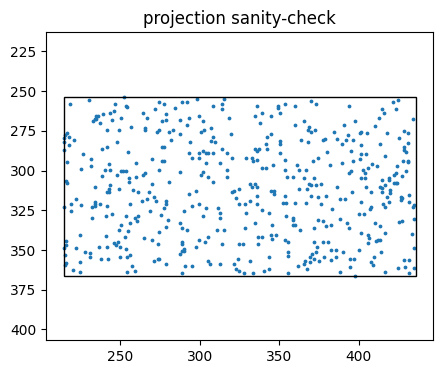

In [14]:
sample = np.random.choice(np.where(inside)[0], size=min(500, inside.sum()), replace=False)
plt.figure(figsize=(5,4))
plt.scatter(u[sample], v[sample], s=3)        # ROI points
plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False))
plt.title("projection sanity-check")
plt.gca().invert_yaxis(); plt.axis('equal'); plt.show()

In [56]:
# Convert units (assumes points are in mm)
points = np.asarray(pcd.points, dtype=np.float64) * MM_TO_M
pcd.points = o3d.utility.Vector3dVector(points)